# 05 — EDA и проверка буста скора
Свежий inference замороженных моделей; новые полевые optical данные не являются метками мусора.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT=Path.cwd()
while not (ROOT/'reports/score_check').exists(): ROOT=ROOT.parent
OUT=ROOT/'reports/score_check'
display(Markdown((OUT/'conclusions.md').read_text()))

# EDA и прогон моделей — 26.09.2026

**Устойчивый прирост от новых EMBLAS/DOORS данных пока не подтверждён: новых обучающих меток мусора нет. Выполнены EDA и свежий inference трёх сохранённых моделей. Прежний выигрыш от MADOS воспроизведён; на новой L2A-проверке результат зависит от порога и ограничен одной test-сценой.**

## Какие данные реально использованы

| source | rows | new_detector_training_labels | new_eligible_T3_events |
| --- | --- | --- | --- |
| EMBLAS | 302 | 0 | 0 |
| DOORS_litter | 33 | 0 | 0 |
| DOORS_TriOS | 27 | 0 | 0 |
| DOORS_MicroPro | 11 | 0 | 0 |
| DOORS_water_quality | 27 | 0 | 0 |
| Romania_July2024 | 8 | 0 | 0 |
| BlackSea_holdout | 12 | 0 | 0 |

Это строки разных типов, их нельзя суммировать как независимые наблюдения. DOORS TriOS — 27 спектров × 451 канал (400–850 нм), без пропусков и отрицательных значений. Есть UTC и координаты. Пригодных оптических кандидатов со спутником — 6/27 измерений, |Δt| 0.67–2.82 ч. Перекрывающиеся тайлы не увеличивают число полевых измерений. Rrs имеет размерность sr⁻¹ и не является ни L2A BOA reflectance, ни rhorc; оценку точности водной атмосферной коррекции здесь не выполняем.

Водные свойства 27 строк: TSM медиана 1.328 мг/л, диапазон 0.433–26.500; хлорофилл медиана 0.266 мг/м³, Secchi медиана 4.0 м. Есть сильная неоднородность мутности; наблюдение с TSM 26.5 мг/л сохранено, не удалено как «ошибка». Это контекст водной оптики, не размеченные классы мусора. Время и свойства водных станций не приписывались litter-трансектам.

12 черноморских кропов: 786432 пикселя, все пока unknown/ignore. Подтверждённых debris/background labels: 0. Сохранены статистики всех 11 каналов, SCL и сравнение с диапазоном p01–p99 MARIDA train water. Значительная разница между сценами/месяцами — описательная характеристика отражения и обработки; выход за диапазон rhorc не является ошибкой L2A, меткой мусора или доказанным OOD классификатора. Модель на зарезервированных кропах не запускалась, чтобы сохранить просмотр разметчиками без подсказок модели.

## Полные контрольные выборки: свежий повтор прежнего результата

Заново вычислены scores для 642168 пикселей × 3 модели (не просто прочитана старая таблица). Совпадение с сохранёнными scores проверено с atol=1e-12. Пороги и веса не менялись, обучения не было.

| dataset | marida_frozen | mados_only | joint | joint_delta |
| --- | --- | --- | --- | --- |
| mados_test | 0.4457 | 0.5529 | 0.5674 | 0.1217 |
| marida_development_test | 0.6410 | 0.6560 | 0.7011 | 0.0601 |

95% paired bootstrap интервалы прироста joint F1, 1000 повторов целыми группами:

| dataset | groups | low | high |
| --- | --- | --- | --- |
| mados_test | 42 | 0.0007 | 0.1723 |
| marida_development_test | 15 | -0.0011 | 0.1446 |

MADOS: +0.1217 F1, MARIDA development: +0.0601. **Это воспроизведение ранее полученного эффекта MADOS, а не новый буст от DOORS.** Для MARIDA интервал включает ноль. Неустановленные пространственно-временные пересечения MADOS/MARIDA по-прежнему ограничивают независимость оценки. Основные метрики учитывают разные исходные validation-пороги; AP также сохранён для оценки ранжирования без одного порога.

## Новая парная проверка L2A/rhorc

Основной результат относится только к 22-12-20_18QYF_0, прежний split=test: **114 размеченных пикселей, 28 debris и 86 water, одна сцена, вне Чёрного моря**. Другой кроп — train, 6 пикселей; он представлен отдельно только как диагностика. Не смешиваем train и test в одной итоговой метрике.

F1 на L2A:

| model | common_marida_threshold | frozen |
| --- | --- | --- |
| marida_frozen | 0.7273 | 0.7273 |
| mados_only | 0.7826 | 0.4865 |
| joint | 0.7826 | 0.5641 |

При сохранённых порогах MARIDA RF обнаруживает 16/28 debris (12 FN), joint — 11/28 (17 FN), MADOS-only — 9/28 (19 FN); FP=0 у всех. То есть joint **ухудшает F1 на 0.1632**, добавляя 5 пропусков. На исходном rhorc того же test-кропа все три модели дают F1=1.

При заранее предусмотренном общем пороге 0.6310449457633717 joint и MADOS-only обнаруживают 18/28 debris, FP=0: F1=0.7826 против 0.7273, **+0.0553**. Это небольшой локальный сигнал и контроль чувствительности к рабочему порогу; общий порог не подбирался по этой сцене. Он **не заменён** в моделях. Поскольку scores RF не калиброванные вероятности, одинаковый числовой порог не означает одинаковую рабочую точку.

У всех моделей AP=1 на этой маленькой L2A-выборке: все 86 отрицательных меток — water со score=0. Ранжирование debris/water здесь сохраняется, а положительные scores на L2A снижаются. В этой сцене совсем нет размеченных судов, пены, органики и других сложных отрицательных классов. Поэтому ни AP=1, ни +0.0553 F1 не доказывают устойчивый перенос. При одной сцене осмысленный межсценовый доверительный интервал невозможен. Срез только high-confidence сохранён отдельно, пороги по нему не настраивались.

## Ответ на вопрос о бусте

- **Прежнее добавление MADOS:** прирост на исследовательских rhorc-выборках воспроизводится.
- **Новые DOORS/EMBLAS:** причинный эффект добавления в обучение пока не измерить — нет совместимых новых detector labels и готовых T3-событий. Модели не переобучались на оптике или неизвестных пикселях.
- **Новый L2A-материал:** у joint нет улучшения с исходным порогом. При общем старом пороге есть +0.0553 на одной сцене, но этого недостаточно для выбора версии или заявления о региональном бусте.

Следующий содержательный эксперимент для скора — собрать размеченные L2A пары **train/validation из нескольких независимых мест/дат**, включая трудный фон; на validation определить порог/обработку и затем оценить замороженный вариант на отдельном test. Для Чёрного моря нужны независимые подтверждённые метки подготовленных 12 сцен; они остаются reserved_holdout. Для концентрации нужны авторские треки/UTC EMBLAS/DOORS, а не перенос водных измерений на litter-ID.

## Артефакты

- [Полный исполненный HTML-анализ](eda_score_check.html), [notebook 05](../../notebooks/05_eda_score_check.ipynb).
- [Все метрики](tables/model_metrics.csv), [пиксельные scores пар](tables/paired_pixel_scores.csv), [изменившиеся ошибки](tables/paired_error_changes.csv).
- [Проверка воспроизведения](tables/reproduction_checks.csv), [интервалы](tables/paired_bootstrap.csv), [готовность данных](tables/data_readiness.csv).
- [Протокол](../../ml/score_check/protocol.md), [команды](../../ml/score_check/README.md), run_manifest.json.

Модели, исходная case-таблица и 36 мастер/индивидуальных файлов labels 12 сцен проверены по SHA256 до/после и не изменились. Перенастройки порогов, публикации или изменения production не выполнялись.


## 1. Готовность и покрытие новых данных

,source,rows,new_detector_training_labels,new_eligible_T3_events,source_table
0,EMBLAS,302,0,0,reports/expansion/tables/emblas_events_pending...
1,DOORS_litter,33,0,0,reports/validation_bridge/tables/doors_transec...
2,DOORS_TriOS,27,0,0,reports/validation_bridge/tables/doors_trios_r...
3,DOORS_MicroPro,11,0,0,reports/validation_bridge/tables/doors_micropr...
4,DOORS_water_quality,27,0,0,reports/validation_bridge/tables/doors_water_q...
5,Romania_July2024,8,0,0,reports/validation_bridge/tables/romania_july2...
6,BlackSea_holdout,12,0,0,reports/validation_bridge/tables/blacksea_hold...


,Unnamed: 0,tsm (mg/l),chl (mg/m3),secchi disk (m)
0,count,27.000000,27.000000,27.000000
1,mean,3.044878,0.487300,4.948148
2,std,5.369931,0.542401,2.879152
3,min,0.433300,0.073200,0.600000
4,25%,0.655000,0.109000,3.200000
5,50%,1.328000,0.266000,4.000000
6,75%,2.141650,0.582500,6.900000
7,max,26.500000,1.968000,11.000000


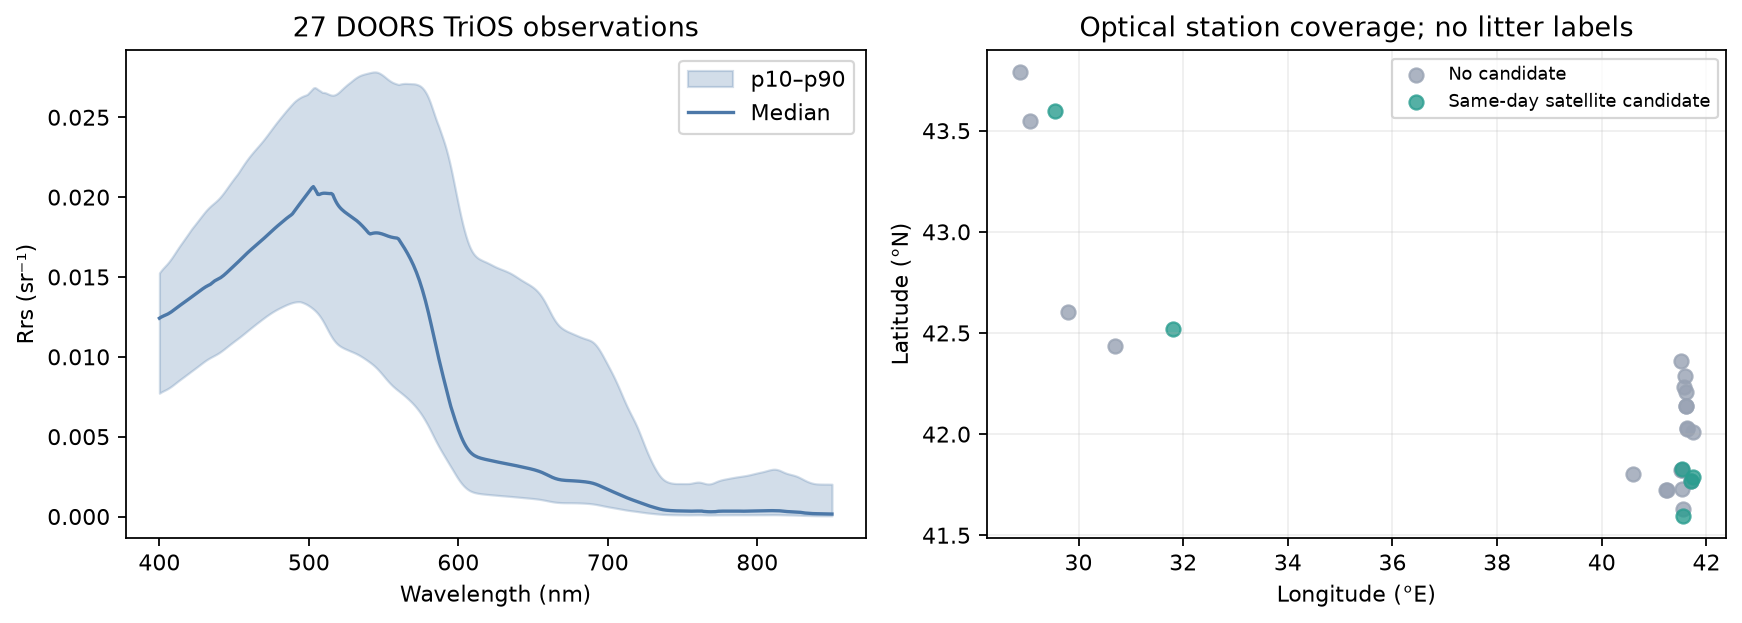

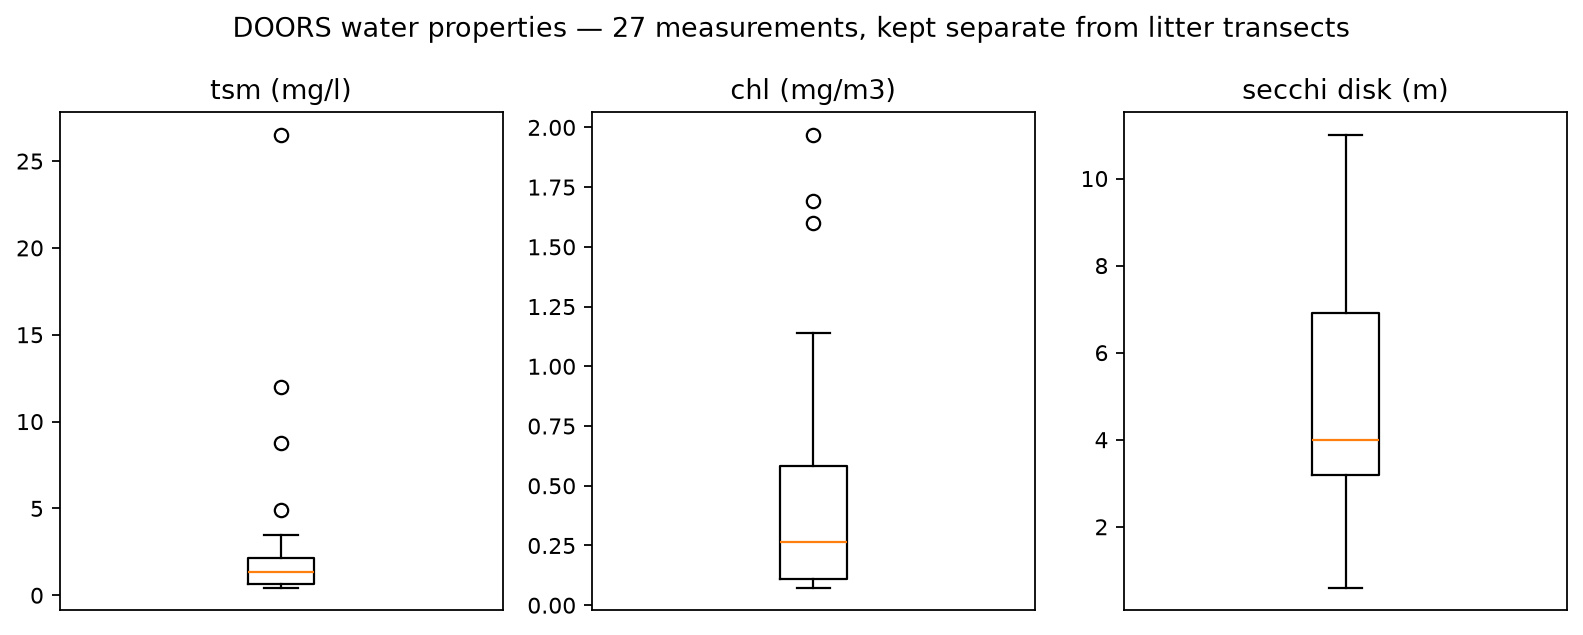

In [2]:
display(pd.read_csv(OUT/'tables/data_readiness.csv'))
display(pd.read_csv(OUT/'tables/water_quality_summary.csv'))
display(Image(filename=str(OUT/'figures/doors_spectra_coverage.png')))
display(Image(filename=str(OUT/'figures/water_quality.png')))

## 2. Радиометрия неразмеченных черноморских сцен

,chip_id,scope,pixels,outside_any_train_water_marginal_range,mean_bands_outside,interpretation
0,novorossiysk-2025-06,all,65536,1.000000,2.774307,L2A versus rhorc description; not classifier O...
1,novorossiysk-2025-06,SCL_water,64684,1.000000,2.768227,L2A versus rhorc description; not classifier O...
2,novorossiysk-2025-09,all,65536,0.000061,0.000153,L2A versus rhorc description; not classifier O...
3,novorossiysk-2025-09,SCL_water,65536,0.000061,0.000153,L2A versus rhorc description; not classifier O...
4,sochi-2025-06,all,65536,1.000000,3.000656,L2A versus rhorc description; not classifier O...
5,sochi-2025-06,SCL_water,65536,1.000000,3.000656,L2A versus rhorc description; not classifier O...
6,sochi-2025-09,all,65536,0.000122,0.000412,L2A versus rhorc description; not classifier O...
7,sochi-2025-09,SCL_water,65536,0.000122,0.000412,L2A versus rhorc description; not classifier O...
8,batumi-2025-06,all,65536,1.000000,11.000000,L2A versus rhorc description; not classifier O...
9,batumi-2025-06,SCL_water,65536,1.000000,11.000000,L2A versus rhorc description; not classifier O...


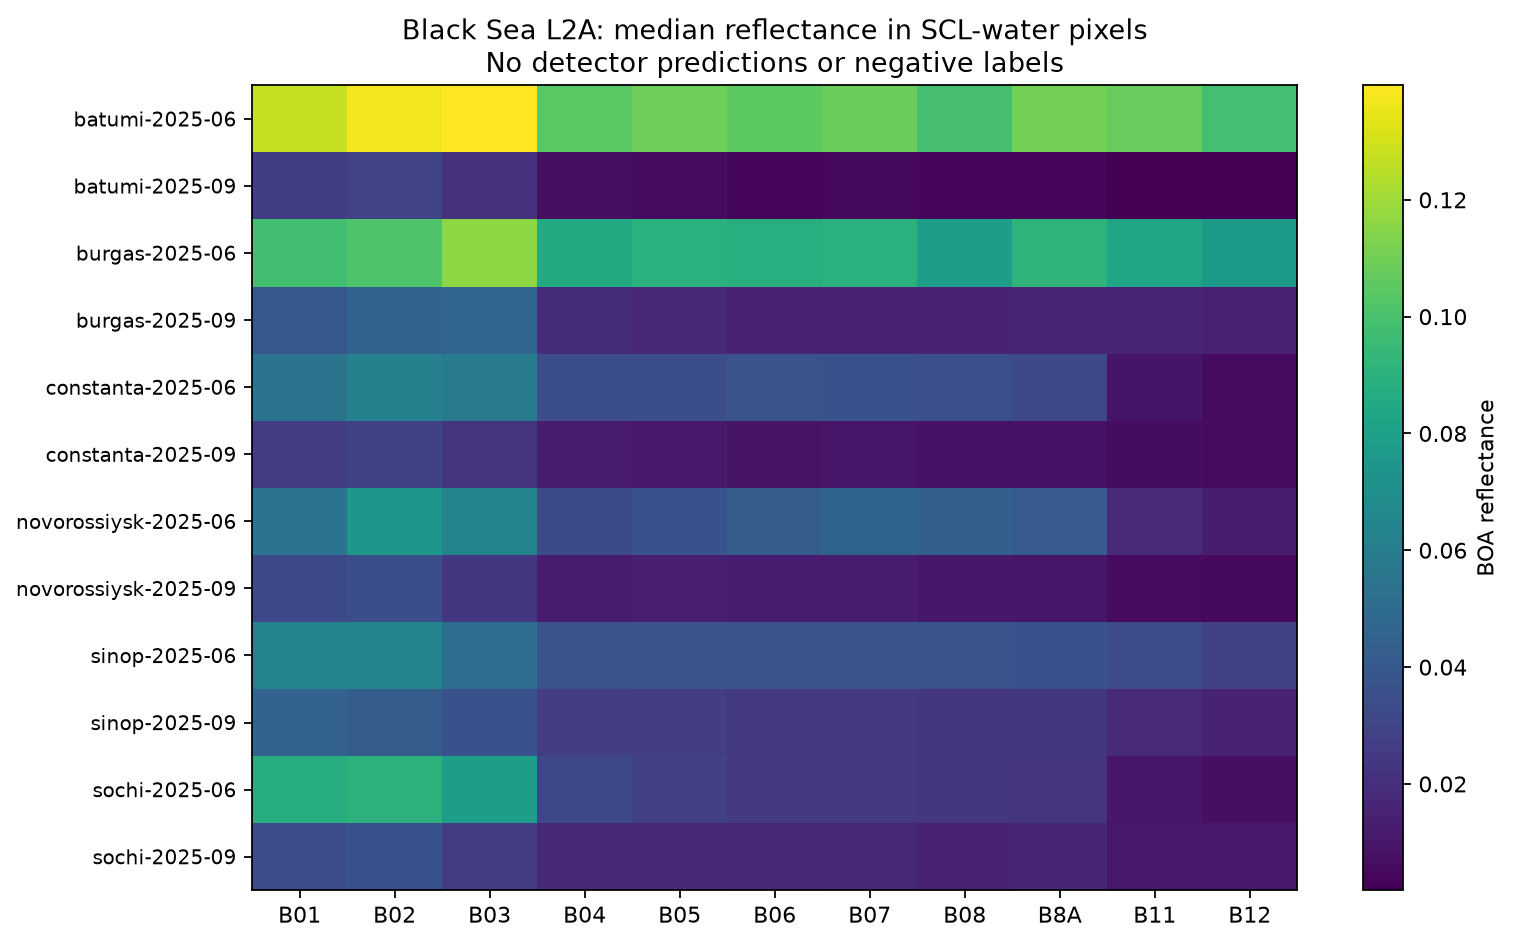

In [3]:
display(pd.read_csv(OUT/'tables/blacksea_radiometry_ranges.csv'))
display(Image(filename=str(OUT/'figures/blacksea_radiometry.png')))

## 3. Повторная проверка полных development-выборок

,dataset,product,split,model,threshold_mode,confidence_mode,groups,pixels,positive_pixels,threshold,tp,fp,fn,tn,precision,recall,f1,iou,false_positive_rate,average_precision
48,marida_development_test,rhorc,development_test,marida_frozen,frozen,all,15,281021,430,0.631045,308,223,122,280368,0.580038,0.716279,0.640999,0.471669,0.000795,0.670157
52,marida_development_test,rhorc,development_test,mados_only,frozen,all,15,281021,430,0.765788,246,74,184,280517,0.768750,0.572093,0.656000,0.488095,0.000264,0.736250
56,marida_development_test,rhorc,development_test,joint,frozen,all,15,281021,430,0.781313,285,98,145,280493,0.744125,0.662791,0.701107,0.539773,0.000349,0.761399
60,mados_test,rhorc,development_test,marida_frozen,frozen,all,42,361147,973,0.631045,589,1081,384,359093,0.352695,0.605344,0.445706,0.286758,0.003001,0.386462
64,mados_test,rhorc,development_test,mados_only,frozen,all,42,361147,973,0.765788,554,477,419,359697,0.537342,0.569373,0.552894,0.382069,0.001324,0.559429
68,mados_test,rhorc,development_test,joint,frozen,all,42,361147,973,0.781313,566,456,407,359718,0.553816,0.581706,0.567419,0.396081,0.001266,0.572942


,dataset,comparison,groups,valid_repeats,low,high,metric
0,mados_test,joint,42,1000,0.352754,0.724691,F1
1,mados_test,mados_only,42,1000,0.339733,0.719706,F1
2,mados_test,marida_frozen,42,1000,0.215851,0.695397,F1
3,mados_test,joint minus marida_frozen,42,1000,0.000659,0.172339,paired_delta_F1
4,mados_test,mados_only minus marida_frozen,42,1000,-0.017938,0.168875,paired_delta_F1
5,marida_development_test,joint,15,1000,0.604010,0.807133,F1
6,marida_development_test,mados_only,15,1000,0.522317,0.780672,F1
7,marida_development_test,marida_frozen,15,1000,0.534996,0.760506,F1
8,marida_development_test,joint minus marida_frozen,15,1000,-0.001122,0.144591,paired_delta_F1
9,marida_development_test,mados_only minus marida_frozen,15,1000,-0.098896,0.133850,paired_delta_F1


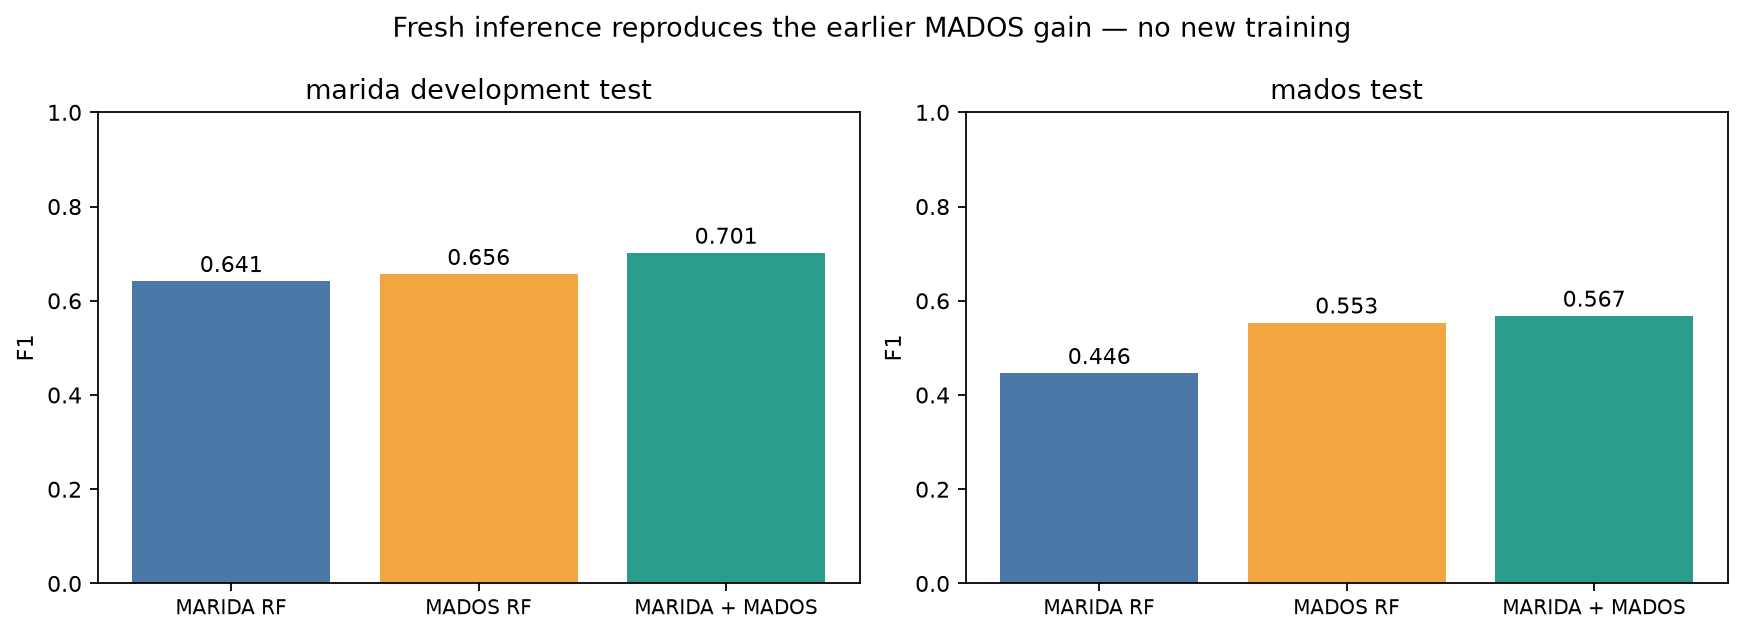

In [4]:
m=pd.read_csv(OUT/'tables/model_metrics.csv')
keep=(m.confidence_mode=='all') & (m.threshold_mode=='frozen')
display(m[keep & ~m.dataset.str.startswith('paired')])
display(pd.read_csv(OUT/'tables/paired_bootstrap.csv'))
display(Image(filename=str(OUT/'figures/full_benchmarks.png')))

## 4. Парные L2A/rhorc: test отдельно от train

,dataset,product,split,model,threshold_mode,confidence_mode,groups,pixels,positive_pixels,threshold,tp,fp,fn,tn,precision,recall,f1,iou,false_positive_rate,average_precision
12,paired_test,L2A,test,marida_frozen,frozen,all,1,114,28,0.631045,16,0,12,86,1.0,0.571429,0.727273,0.571429,0.0,1.0
13,paired_test,L2A,test,marida_frozen,frozen,high_only,1,105,19,0.631045,8,0,11,86,1.0,0.421053,0.592593,0.421053,0.0,1.0
14,paired_test,L2A,test,marida_frozen,common_marida_threshold,all,1,114,28,0.631045,16,0,12,86,1.0,0.571429,0.727273,0.571429,0.0,1.0
15,paired_test,L2A,test,marida_frozen,common_marida_threshold,high_only,1,105,19,0.631045,8,0,11,86,1.0,0.421053,0.592593,0.421053,0.0,1.0
16,paired_test,L2A,test,mados_only,frozen,all,1,114,28,0.765788,9,0,19,86,1.0,0.321429,0.486486,0.321429,0.0,1.0
17,paired_test,L2A,test,mados_only,frozen,high_only,1,105,19,0.765788,8,0,11,86,1.0,0.421053,0.592593,0.421053,0.0,1.0
18,paired_test,L2A,test,mados_only,common_marida_threshold,all,1,114,28,0.631045,18,0,10,86,1.0,0.642857,0.782609,0.642857,0.0,1.0
19,paired_test,L2A,test,mados_only,common_marida_threshold,high_only,1,105,19,0.631045,11,0,8,86,1.0,0.578947,0.733333,0.578947,0.0,1.0
20,paired_test,L2A,test,joint,frozen,all,1,114,28,0.781313,11,0,17,86,1.0,0.392857,0.564103,0.392857,0.0,1.0
21,paired_test,L2A,test,joint,frozen,high_only,1,105,19,0.781313,8,0,11,86,1.0,0.421053,0.592593,0.421053,0.0,1.0


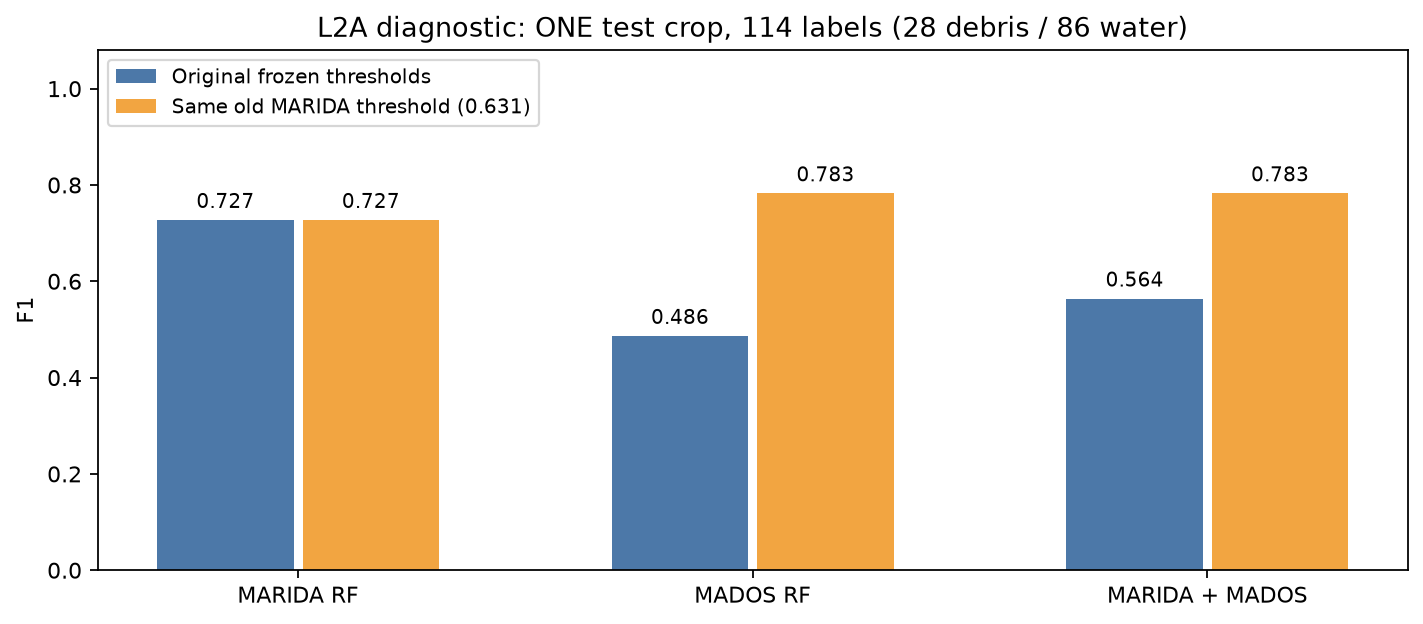

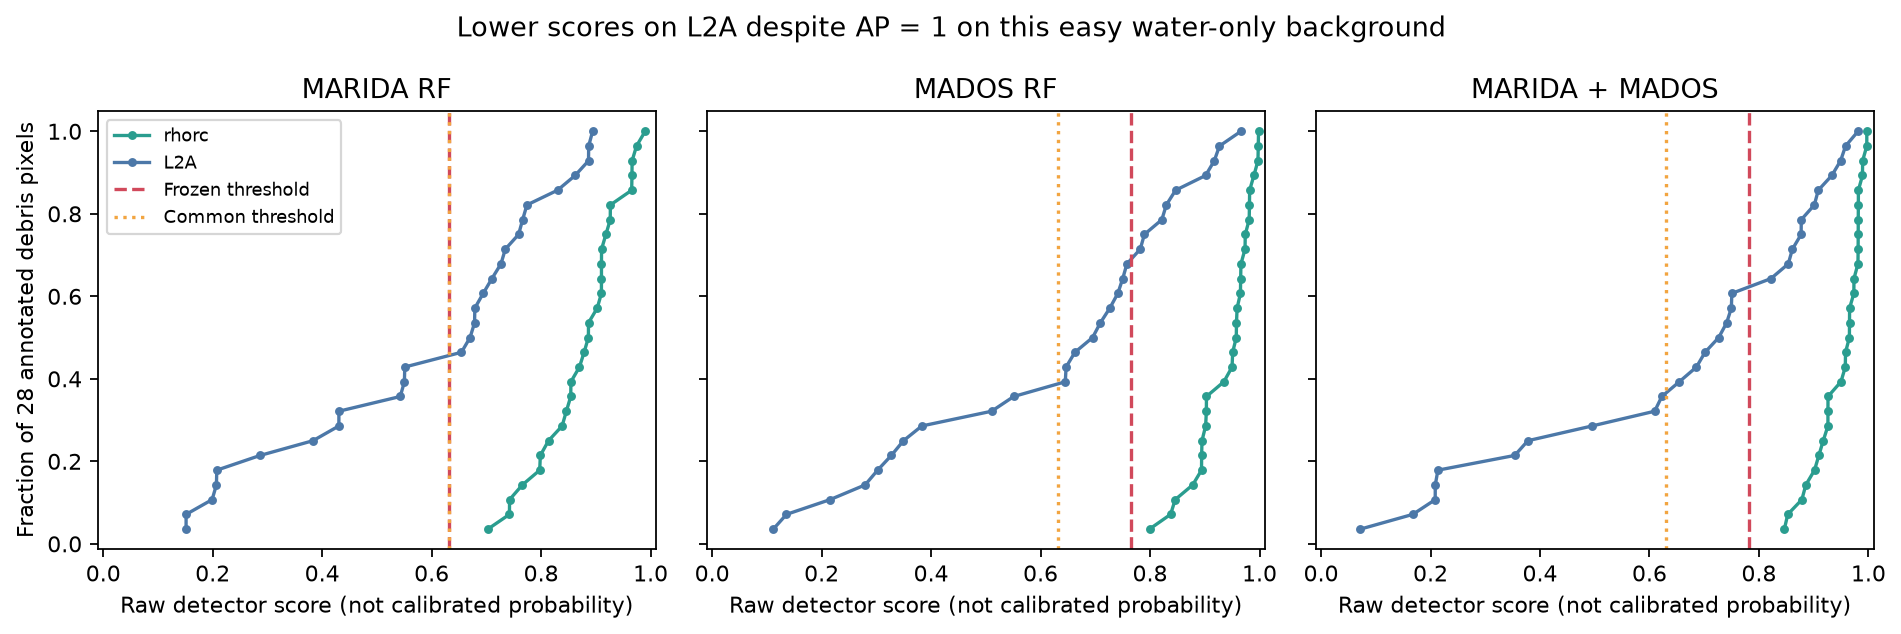

,patch_id,split,product,model,corrected_errors,introduced_errors,recovered_debris,lost_debris,removed_false_positives,added_false_positives
0,22-12-20_18QYF_0,test,rhorc,mados_only,0,0,0,0,0,0
1,22-12-20_18QYF_0,test,rhorc,joint,0,0,0,0,0,0
2,22-12-20_18QYF_0,test,L2A,mados_only,1,8,1,8,0,0
3,22-12-20_18QYF_0,test,L2A,joint,0,5,0,5,0,0
4,24-4-19_36JUN_0,train,rhorc,mados_only,0,2,0,2,0,0
5,24-4-19_36JUN_0,train,rhorc,joint,0,0,0,0,0,0
6,24-4-19_36JUN_0,train,L2A,mados_only,0,1,0,1,0,0
7,24-4-19_36JUN_0,train,L2A,joint,0,1,0,1,0,0


In [5]:
display(m[(m.dataset=='paired_test') & (m['product']=='L2A')])
display(Image(filename=str(OUT/'figures/l2a_threshold_effect.png')))
display(Image(filename=str(OUT/'figures/paired_score_shift.png')))
display(pd.read_csv(OUT/'tables/paired_error_changes.csv'))

## 5. Независимый пересчёт всех confusion matrices и защита входов

In [6]:
import numpy as np, json, hashlib
manifest=json.loads((OUT/'run_manifest.json').read_text())
for rel,expected in manifest['protected_input_sha256'].items():
    assert hashlib.sha256((ROOT/rel).read_bytes()).hexdigest()==expected
thresholds=manifest['thresholds']
for dataset in ['mados_test','marida_development_test']:
    d=dict(np.load(ROOT/f'data/processed/score_check/{dataset}_scores.npz'))
    for model,t in thresholds.items():
        y=d['y']==1; p=d[model]>=t
        counts={'tp':int((y&p).sum()),'fp':int((~y&p).sum()),'fn':int((y&~p).sum()),'tn':int((~y&~p).sum())}
        row=m[(m.dataset==dataset)&(m.model==model)&(m.threshold_mode=='frozen')&(m.confidence_mode=='all')].iloc[0]
        assert all(row[k]==v for k,v in counts.items())
        assert np.isclose(row.f1,2*counts['tp']/(2*counts['tp']+counts['fp']+counts['fn']))
assert not manifest['training_performed']
assert not manifest['new_blacksea_detector_predictions']
print('All 6 full-benchmark confusion matrices reproduced; protected hashes unchanged; new labels = 0.')

All 6 full-benchmark confusion matrices reproduced; protected hashes unchanged; new labels = 0.
